# Spotify Song Recommendation System

Content-based recommender using Spotify audio features (1921-2020, 170k+ tracks).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances

pd.set_option('display.max_columns', None)

## 1. Load and explore the data

In [2]:
data = pd.read_csv('../data/data.csv')
print(data.shape)
data.head()

(169909, 19)


,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
0,0.995,['Carl Woitschach'],0.708,158648,0.1950,0,6KbQ3uYMLKb5jDxLF7wYDD,0.563,10,0.1510,-12.428,1,Singende Bataillone 1. Teil,0,1928,0.0506,118.469,0.7790,1928
1,0.994,"['Robert Schumann', 'Vladimir Horowitz']",0.379,282133,0.0135,0,6KuQTIu1KoTTkLXKrwlLPV,0.901,8,0.0763,-28.454,1,"Fantasiestücke, Op. 111: Più tosto lento",0,1928,0.0462,83.972,0.0767,1928
2,0.604,['Seweryn Goszczyński'],0.749,104300,0.2200,0,6L63VW0PibdM1HDSBoqnoM,0.000,5,0.1190,-19.924,0,Chapter 1.18 - Zamek kaniowski,0,1928,0.9290,107.177,0.8800,1928
3,0.995,['Francisco Canaro'],0.781,180760,0.1300,0,6M94FkXd15sOAOQYRnWPN8,0.887,1,0.1110,-14.734,0,Bebamos Juntos - Instrumental (Remasterizado),0,1928-09-25,0.0926,108.003,0.7200,1928
4,0.990,"['Frédéric Chopin', 'Vladimir Horowitz']",0.210,687733,0.2040,0,6N6tiFZ9vLTSOIxkj8qKrd,0.908,11,0.0980,-16.829,1,"Polonaise-Fantaisie in A-Flat Major, Op. 61",1,1928,0.0424,62.149,0.0693,1928


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169909 entries, 0 to 169908
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   acousticness      169909 non-null  float64
 1   artists           169909 non-null  object 
 2   danceability      169909 non-null  float64
 3   duration_ms       169909 non-null  int64  
 4   energy            169909 non-null  float64
 5   explicit          169909 non-null  int64  
 6   id                169909 non-null  object 
 7   instrumentalness  169909 non-null  float64
 8   key               169909 non-null  int64  
 9   liveness          169909 non-null  float64
 10  loudness          169909 non-null  float64
 11  mode              169909 non-null  int64  
 12  name              169909 non-null  object 
 13  popularity        169909 non-null  int64  
 14  release_date      169909 non-null  object 
 15  speechiness       169909 non-null  float64
 16  tempo             16

In [4]:
data.isnull().sum()

acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
valence             0
year                0
dtype: int64

## 2. Correlation between audio features

Drop identifier/metadata columns that don't describe the sound of the track itself.

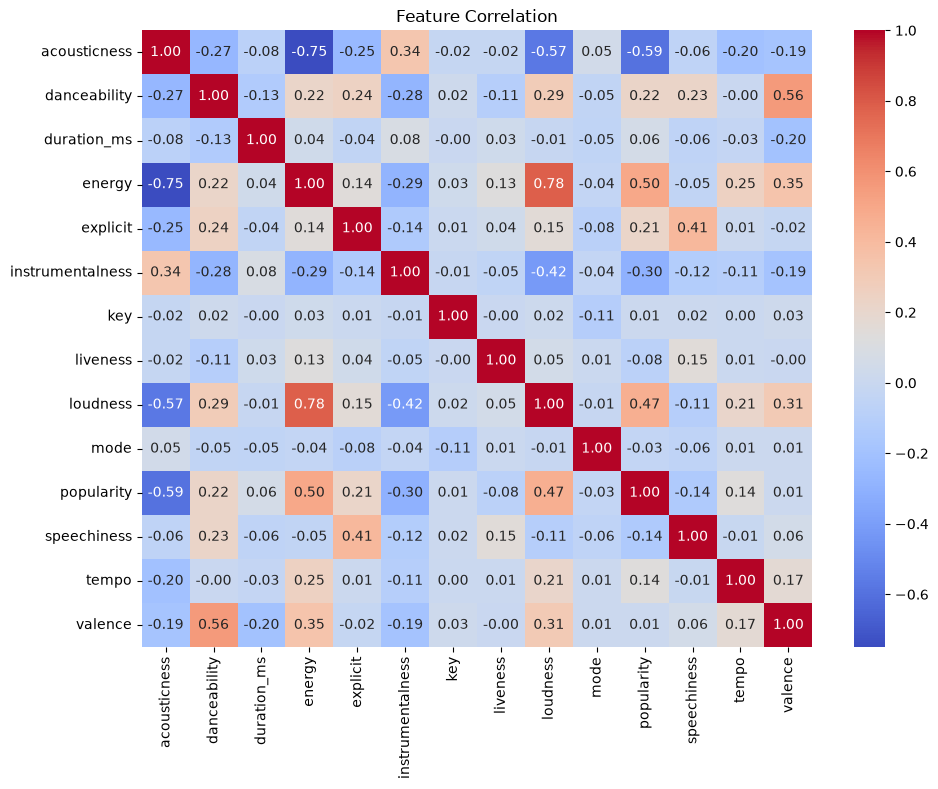

In [5]:
df = data.drop(columns=['id', 'name', 'artists', 'release_date', 'year'])

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png')
plt.show()

## 3. Scale the audio features

Only the continuous audio-feature columns are scaled (not `id`, `name`, `artists`, `release_date`, `year`,
or the already-categorical `key`/`mode`/`explicit`). `fit_transform` returns the scaled values, which are
assigned back into the dataframe.

In [6]:
feature_cols = ['acousticness', 'danceability', 'duration_ms', 'energy',
                'instrumentalness', 'liveness', 'loudness', 'speechiness',
                'tempo', 'valence']

scaler = MinMaxScaler()
data[feature_cols] = scaler.fit_transform(data[feature_cols])
data[feature_cols].describe()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000
mean,0.495195,0.544686,0.041920,0.488593,0.161937,0.206690,0.761565,0.097067,0.479116,0.532095
std,0.378140,0.177475,0.022474,0.267390,0.309329,0.176796,0.088744,0.154734,0.125883,0.262408
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.094880,0.422065,0.030737,0.263000,0.000000,0.098400,0.713022,0.036017,0.383119,0.322000
50%,0.493976,0.554656,0.037695,0.481000,0.000204,0.135000,0.775601,0.046440,0.470226,0.544000
75%,0.891566,0.675101,0.047765,0.710000,0.086800,0.263000,0.828158,0.077812,0.555989,0.749000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 4. (Optional) Cluster songs by sound

Adds a `cluster` label so the recommender can also account for overall "sound category",
not just raw feature distance.

In [7]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(data[feature_cols])
data['cluster'].value_counts().sort_index()

cluster
0     6503
1    26617
2    27863
3    13269
4    33383
5    19211
6    21725
7    10415
8     4245
9     6678
Name: count, dtype: int64

## 5. Build the recommender

Distances to every other track are computed in one vectorized call
(`sklearn.metrics.pairwise.euclidean_distances`) instead of a Python `for` loop over rows,
which is what makes this usable on 170k+ tracks.

In [8]:
class SpotifyRecommender:
    def __init__(self, dataset, feature_cols):
        self.dataset = dataset
        self.feature_cols = feature_cols

    def recommend(self, song_name, amount=5):
        matches = self.dataset[self.dataset['name'].str.lower() == song_name.lower()]
        if matches.empty:
            raise ValueError(f"'{song_name}' not found in dataset")

        target = matches.iloc[[0]][self.feature_cols].values
        candidates = self.dataset[self.dataset['name'].str.lower() != song_name.lower()].copy()
        candidates['distance'] = euclidean_distances(target, candidates[self.feature_cols].values)[0]

        return candidates.sort_values('distance')[['artists', 'name', 'distance']].head(amount)

recommender = SpotifyRecommender(data, feature_cols)

## 6. Try it out

In [9]:
recommender.recommend("WonderWall", amount=10)

,artists,name,distance
168468,['Red Hot Chili Peppers'],Make You Feel Better,0.051931
77445,['frederic'],Oddloop,0.064242
68309,"[""Jimmie's Chicken Shack""]",Another Day,0.072490
159730,['American Hi-Fi'],The Art Of Losing,0.074887
76989,['Gary Allan'],Get Off On The Pain,0.077185
7265,['Godsmack'],"Come Together - Live From Fox Theatre Detroit,...",0.078483
69194,['The Red Jumpsuit Apparatus'],Waiting,0.078943
72708,['The Monkees'],The Girl I Knew Somewhere - Single Version; St...,0.085601
140061,['Blondie'],11:59,0.091771
39070,['Foo Fighters'],Monkey Wrench,0.092366
